In [ ]:
#EOQ (Economic Order Quantity)

#ABC Inventory Classification

#Forecast accuracy (MAPE)

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("supply_chain_data.csv")

# Demand
df["Annual_Demand"] = df["Number of products sold"]

# Ordering cost assumption
ordering_cost = df["Costs"].mean()

# Holding cost assumption (20% of product price)
df["Holding_Cost"] = df["Price"] * 0.20

# EOQ Formula
df["EOQ"] = np.sqrt((2 * df["Annual_Demand"] * ordering_cost) / df["Holding_Cost"])

# Display EOQ
print(df[["SKU","Annual_Demand","EOQ"]].head())

    SKU  Annual_Demand         EOQ
0  SKU0            802  246.583079
1  SKU1            736  512.270222
2  SKU2              8   61.158462
3  SKU3             83   84.746572
4  SKU4            871  979.419324


In [2]:
# Calculate total revenue per SKU
sku_revenue = df.groupby('SKU')['Revenue generated'].sum().reset_index()

# Sort products by revenue
sku_revenue = sku_revenue.sort_values(by='Revenue generated', ascending=False)

# Calculate cumulative revenue percentage
sku_revenue['Cumulative %'] = (
    sku_revenue['Revenue generated'].cumsum() /
    sku_revenue['Revenue generated'].sum()
)

# ABC classification function
def classify_abc(x):
    if x <= 0.80:
        return 'A'
    elif x <= 0.95:
        return 'B'
    else:
        return 'C'

sku_revenue['ABC Class'] = sku_revenue['Cumulative %'].apply(classify_abc)

sku_revenue.head()

,SKU,Revenue generated,Cumulative %,ABC Class
47,SKU51,9866.465458,0.017082,A
32,SKU38,9692.318040,0.033862,A
25,SKU31,9655.135103,0.050578,A
90,SKU90,9592.633570,0.067185,A
12,SKU2,9577.749626,0.083767,A


In [3]:
df = df.merge(
    sku_revenue[['SKU','ABC Class']],
    on='SKU',
    how='left'
)

df[['SKU','ABC Class']].head()

,SKU,ABC Class
0,SKU0,A
1,SKU1,A
2,SKU2,A
3,SKU3,A
4,SKU4,B


In [9]:
# Sort by revenue
abc = df.sort_values(by="Revenue generated", ascending=False)

# cumulative revenue
abc["Cum_Revenue"] = abc["Revenue generated"].cumsum()

# cumulative percentage
abc["Cum_Percentage"] = 100 * abc["Cum_Revenue"] / abc["Revenue generated"].sum()

# classification function
def classify_abc(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

abc["ABC_Class"] = abc["Cum_Percentage"].apply(classify_abc)

abc.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Transportation modes,Routes,Costs,Annual_Demand,Holding_Cost,EOQ,ABC Class,Cum_Revenue,Cum_Percentage,ABC_Class
51,haircare,SKU51,26.700761,61,154,9866.465458,Male,100,4,52,...,Road,Route A,694.982318,154,5.340152,174.713814,A,9866.465458,1.708169,A
38,cosmetics,SKU38,52.075931,75,705,9692.318040,Non-binary,69,1,88,...,Air,Route B,339.672870,705,10.415186,267.673108,A,19558.783498,3.386188,A
31,skincare,SKU31,50.847393,28,168,9655.135103,Male,6,17,44,...,Rail,Route C,609.379207,168,10.169479,132.235785,A,29213.918601,5.057769,A
90,skincare,SKU90,13.881914,56,320,9592.633570,Non-binary,66,18,96,...,Rail,Route B,990.078473,320,2.776383,349.284268,A,38806.552171,6.718530,A
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Air,Route C,141.920282,8,2.263937,61.158462,A,48384.301797,8.376714,A


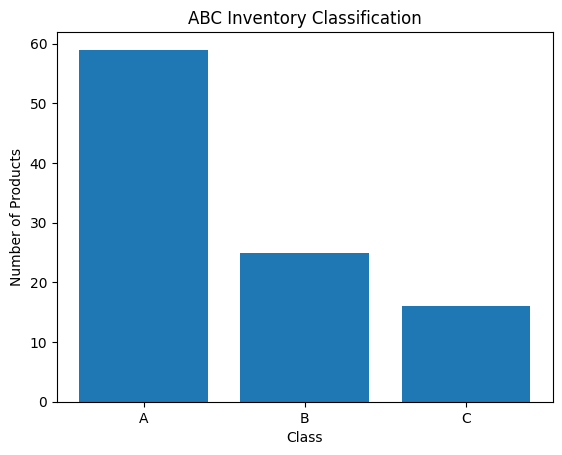

In [10]:

#ABC Visualization 

abc_counts = abc["ABC_Class"].value_counts()

plt.bar(abc_counts.index, abc_counts.values)
plt.title("ABC Inventory Classification")
plt.xlabel("Class")
plt.ylabel("Number of Products")
plt.show()

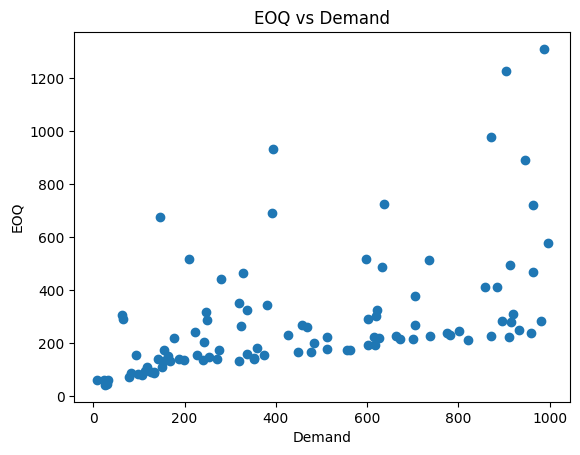

In [8]:
#EOQ Visualization

plt.scatter(df["Annual_Demand"], df["EOQ"])
plt.xlabel("Demand")
plt.ylabel("EOQ")
plt.title("EOQ vs Demand")
plt.show()

In [11]:
# Sort by SKU to simulate time order
df = df.sort_values("SKU")

# Simple rolling forecast
df["Forecast"] = df["Number of products sold"].rolling(window=3).mean()

# Remove NaN rows
forecast_df = df.dropna(subset=["Forecast"])

# MAPE calculation
forecast_df["APE"] = abs((forecast_df["Number of products sold"] - forecast_df["Forecast"]) /
                          forecast_df["Number of products sold"])

MAPE = forecast_df["APE"].mean() * 100

print("MAPE:", round(MAPE,2), "%")

MAPE: 172.26 %


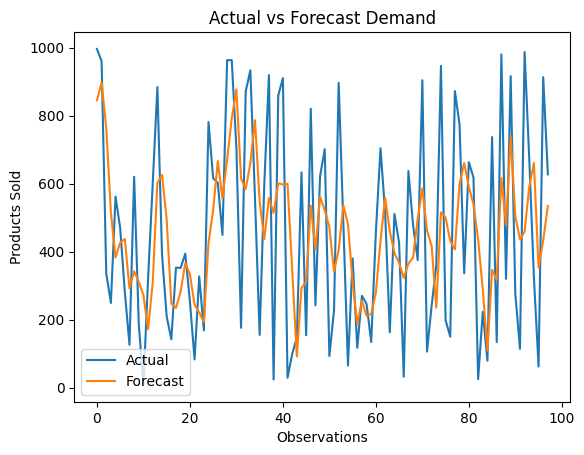

In [12]:

#Actual vs Forecast Plot (Best for MAPE explanation)

plt.figure()

plt.plot(forecast_df["Number of products sold"].values, label="Actual")
plt.plot(forecast_df["Forecast"].values, label="Forecast")

plt.title("Actual vs Forecast Demand")
plt.xlabel("Observations")
plt.ylabel("Products Sold")
plt.legend()

plt.show()